In [1]:
import torch
from transformers import AutoModelForZeroShotObjectDetection, AutoProcessor
from transformers.image_utils import load_image

In [2]:
# Prepare processor and model
model_id = "iSEE-Laboratory/llmdet_tiny"
device = "cuda" if torch.cuda.is_available() else "cpu"
processor = AutoProcessor.from_pretrained(model_id)
model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).to(device)

preprocessor_config.json:   0%|          | 0.00/511 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/692M [00:00<?, ?B/s]

In [7]:
# Prepare inputs
image_url = "https://github.com/phamleduy04/se4351-mobile-f25/blob/main/example.jpg?raw=true"
image = load_image(image_url)
text_labels = [["a door", "a plaque"]]
inputs = processor(images=image, text=text_labels, return_tensors="pt").to(device)

In [8]:
# Run inference
with torch.no_grad():
    outputs = model(**inputs)

# Postprocess outputs
results = processor.post_process_grounded_object_detection(
    outputs,
    threshold=0.4,
    target_sizes=[(image.height, image.width)]
)

In [9]:
# Retrieve the first image result
result = results[0]
for box, score, labels in zip(result["boxes"], result["scores"], result["labels"]):
    box = [round(x, 2) for x in box.tolist()]
    print(f"Detected {labels} with confidence {round(score.item(), 3)} at location {box}")

Detected a door with confidence 0.62 at location [17.89, 1.87, 171.59, 530.2]
Detected a plaque with confidence 0.514 at location [189.24, 227.32, 215.74, 259.69]


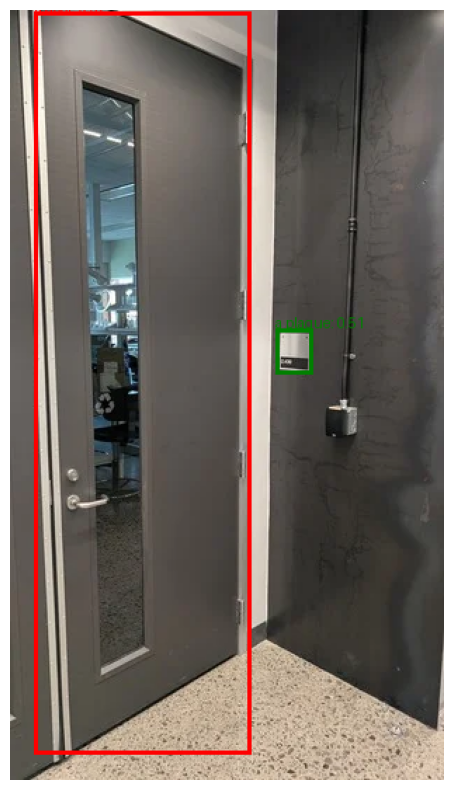

In [11]:
import matplotlib.pyplot as plt
from PIL import ImageDraw

# Create a copy of the image to draw on
draw_image = image.copy()
draw = ImageDraw.Draw(draw_image)

# Retrieve the first image result
result = results[0]

# Define colors for bounding boxes
colors = ['red', 'green', 'blue', 'purple', 'orange', 'cyan', 'magenta', 'yellow']

for i, (box, score, label) in enumerate(zip(result["boxes"], result["scores"], result["text_labels"])):
    # Convert tensor box to list and round coordinates
    box = [round(x, 2) for x in box.tolist()]
    # Extract coordinates
    x_min, y_min, x_max, y_max = box

    # Choose a color from the defined list
    color = colors[i % len(colors)]

    # Draw the bounding box
    draw.rectangle([x_min, y_min, x_max, y_max], outline=color, width=3)

    # Draw the label and score
    label_text = f"{label}: {score:.2f}"
    # You might need to adjust font size and position based on your image size
    draw.text((x_min, y_min - 10), label_text, fill=color)

# Display the annotated image
plt.figure(figsize=(10, 10))
plt.imshow(draw_image)
plt.axis('off') # Hide axes
plt.show()